# Phase 8 — Portfolio Scenario Simulator & Capital Stress Engine

This notebook converts the Insurance Digital Twin into a **decision simulation platform**.

Inputs:

• Phase 6 frequency model outputs  
• Phase 7 fraud policy artefacts  
• Portfolio policies and claims  

Outputs:

• Scenario stress projections  
• Monte Carlo loss distribution  
• Capital stress estimation  
• Pricing optimisation simulation  
• Portfolio strategy optimisation  
• Executive dashboard outputs  

This phase mirrors how internal insurer analytics platforms support
portfolio steering and board-level risk discussions.

In [1]:
# Importing the dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

In [2]:
# Loading Profile Data (repo-relative)

DATA_DIR = Path("V:/Himika/Project/insurance-digital-twin/data/raw")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Expected repo path data/raw not found. "
        "Run Phase 1 generator or update DATA_DIR to a valid repo-relative location."
    )

claims = pd.read_csv(DATA_DIR / "claims.csv")
policies = pd.read_csv(DATA_DIR / "policies.csv")

print("Claims:", claims.shape)
print("Policies:", policies.shape)

# quick schema guards
req_claim_cols = {"claim_id","policy_id","paid_amount","outstanding_reserve","is_fraud"}
req_pol_cols = {"policy_id","product_type","channel","start_date","end_date","base_annual_premium"}
assert req_claim_cols.issubset(claims.columns), f"Missing claim cols: {req_claim_cols - set(claims.columns)}"
assert req_pol_cols.issubset(policies.columns), f"Missing policy cols: {req_pol_cols - set(policies.columns)}"

Claims: (148907, 12)
Policies: (120000, 11)


## Phase 6 Inputs (Pricing Frequency)

We consume Phase 6 outputs as rating factors (relativities).
This keeps Week 8 independent of model-fitting code and aligns with governed pipelines.

In [3]:
# Loading Phase 6 Artefacts

PH6 = Path("outputs/phase6")
for p in [
    PH6/"relativities_product.csv",
    PH6/"relativities_channel.csv",
    PH6/"relativities_vehicle_age_band.csv",
    PH6/"phase6_exec_metrics.json"
]:
    if not p.exists():
        raise FileNotFoundError(f"Missing Phase 6 artefact: {p}")

rel_prod = pd.read_csv(PH6/"relativities_product.csv")
rel_channel = pd.read_csv(PH6/"relativities_channel.csv")
rel_vehicle = pd.read_csv(PH6/"relativities_vehicle_age_band.csv")

with open(PH6/"phase6_exec_metrics.json") as f:
    phase6_metrics = json.load(f)

print("Frequency model:", phase6_metrics.get("model_type","(missing)"))

# schema checks
for name, df_ in [("product", rel_prod), ("channel", rel_channel), ("vehicle_age_band", rel_vehicle)]:
    assert {"level","relativity"}.issubset(df_.columns), f"{name} relativities must have columns: level, relativity"

Frequency model: Negative Binomial (NB2)


## Phase 7 Inputs (Fraud / SIU Policy)

We load Phase 7 decision artefacts so scenario outcomes can be connected to operational controls
(e.g., SIU review capacity and threshold policies).

In [4]:
# Loading Phase 7 Artefacts

PH7 = Path("outputs/phase7")
for p in [
    PH7/"phase7_siu_capacity_table.csv",
    PH7/"phase7_siu_cost_capacity_table.csv",
    PH7/"phase7_siu_threshold_policy_table.csv"
]:
    if not p.exists():
        raise FileNotFoundError(f"Missing Phase 7 artefact: {p}")

siu_capacity = pd.read_csv(PH7/"phase7_siu_capacity_table.csv")
siu_cost = pd.read_csv(PH7/"phase7_siu_cost_capacity_table.csv")
siu_threshold = pd.read_csv(PH7/"phase7_siu_threshold_policy_table.csv")

print("SIU capacity rows:", siu_capacity.shape)

SIU capacity rows: (4, 3)


## Exposure Basis

Exposure is computed from policy duration in years.
For annual personal lines policies, exposure is capped at 1.0 policy-year.

In [5]:
# Exposure Calculation

policies["start_date"] = pd.to_datetime(policies["start_date"], errors="coerce")
policies["end_date"] = pd.to_datetime(policies["end_date"], errors="coerce")

bad_dates = policies["start_date"].isna().sum() + policies["end_date"].isna().sum()
if bad_dates > 0:
    raise ValueError(f"Found missing/invalid policy dates: {bad_dates}. Fix upstream data freeze or parsing.")

policies["exposure"] = (policies["end_date"] - policies["start_date"]).dt.days / 365.25

# annual personal lines → cap to 1 policy-year; clip negatives
policies["exposure"] = policies["exposure"].clip(lower=0, upper=1.0)

## Frequency Calibration

Relativities define shape (risk differentiation) but not the absolute level.
We calibrate the base frequency so expected claim volume matches observed non-fraud volume.

In [6]:
# Pricing Relativities (Phase 6 factors → expected frequency)

df = policies.copy()

df = df.merge(
    rel_prod.rename(columns={"level": "product_type", "relativity": "relativity_prod"}),
    on="product_type",
    how="left"
)

df = df.merge(
    rel_channel.rename(columns={"level": "channel", "relativity": "relativity_channel"}),
    on="channel",
    how="left"
)

# fallback: base levels not present in exported tables should map to 1.0
df["relativity_prod"] = df["relativity_prod"].fillna(1.0)
df["relativity_channel"] = df["relativity_channel"].fillna(1.0)

# initial placeholder level (will be calibrated)
base_frequency = 0.05

df["expected_frequency"] = (
    base_frequency
    * df["relativity_prod"]
    * df["relativity_channel"]
    * df["exposure"]
)

# Calibrate base frequency to match observed non-fraud claim volume
obs_claims = claims.loc[claims["is_fraud"] == 0].groupby("policy_id")["claim_id"].count().sum()
exp_claims_raw = (df["expected_frequency"] / base_frequency).sum()
base_frequency_cal = obs_claims / max(exp_claims_raw, 1e-9)

df["expected_frequency"] = (
    base_frequency_cal
    * df["relativity_prod"]
    * df["relativity_channel"]
    * df["exposure"]
)

print("Base frequency calibrated:", base_frequency_cal)
print("Expected portfolio claims (non-fraud calibrated):", df["expected_frequency"].sum())

Base frequency calibrated: 0.42707998670210123
Expected portfolio claims (non-fraud calibrated): 137588.0


## Severity Definition (Incurred Proxy)

Severity is defined as:
`severity = max(paid,0) + max(outstanding_reserve,0)`

This approximates incurred cost and remains valid for open claims.

In [7]:
# Severity Baseline (incurred proxy)

claims["severity"] = (
    pd.to_numeric(claims["paid_amount"], errors="coerce").fillna(0).clip(lower=0)
    + pd.to_numeric(claims["outstanding_reserve"], errors="coerce").fillna(0).clip(lower=0)
)

mean_severity = claims["severity"].mean()
std_severity = claims["severity"].std()

# non-zero severity sample for lognormal calibration
sev_pos = claims.loc[claims["severity"] > 0, "severity"]
if sev_pos.empty:
    raise ValueError("No positive severities found; cannot calibrate severity distribution.")

print("Mean severity:", mean_severity)
print("Positive severity count:", len(sev_pos))

Mean severity: 4663.614427226067
Positive severity count: 134444


In [8]:
# Scenario Definition

scenario = {
    "inflation_shock":0.12,
    "frequency_shock":0.08,
    "fraud_multiplier":1.25
}

In [9]:
# Apply Scenario

df["freq_stressed"] = df["expected_frequency"] * (1 + scenario["frequency_shock"])

# Severity inflation
mean_severity_stressed = mean_severity * (1 + scenario["inflation_shock"])

df["expected_loss"] = df["freq_stressed"] * mean_severity_stressed

In [10]:
# Fraud Overlay

df["fraud_adjusted_loss"] = np.where(
    df["product_type"] == "motor",
    df["expected_loss"] * scenario["fraud_multiplier"],
    df["expected_loss"]
)

In [11]:
# Portfolio Expected Loss

portfolio_loss = df["fraud_adjusted_loss"].sum()

print("Expected portfolio loss:", portfolio_loss)

Expected portfolio loss: 863742147.9688749


In [12]:
# Monte Carlo Simulation (collective risk model)

n_sim = 5000

portfolio_lambda = df["freq_stressed"].sum()

# severity distribution parameters (lognormal calibrated to mean)
sev_pos = claims.loc[claims["severity"] > 0, "severity"]
log_sev = np.log(sev_pos)
sev_sigma = log_sev.std()

sev_mu = np.log(mean_severity_stressed) - (sev_sigma**2) / 2

# OPTIONAL: claim count overdispersion proxy (Gamma-Poisson mixture ≈ NB)
USE_NB_MIXTURE = True
k = 50  # higher → closer to Poisson; lower → fatter count tail

losses = []

for _ in range(n_sim):
    if USE_NB_MIXTURE:
        theta = portfolio_lambda / k
        lambda_mixed = np.random.gamma(shape=k, scale=theta)
        total_claims = np.random.poisson(lambda_mixed)
    else:
        total_claims = np.random.poisson(portfolio_lambda)

    severities = np.random.lognormal(mean=sev_mu, sigma=sev_sigma, size=total_claims)
    losses.append(severities.sum())

losses = np.array(losses)

print("Mean simulated loss:", np.mean(losses))
print("Simulated claim frequency (lambda):", portfolio_lambda)
print("Severity params (mu, sigma):", sev_mu, sev_sigma)

Mean simulated loss: 778095953.2837594
Simulated claim frequency (lambda): 148595.03999999998
Severity params (mu, sigma): 7.962092740267959 1.0943326730704543


## Catastrophe Simulation Layer

Attritional portfolio losses alone do not fully represent insurer capital risk.

To make the Digital Twin more realistic, we introduce a simple catastrophe layer:

- low annual probability
- high loss severity
- additive shock to portfolio losses

This creates a more realistic right tail in the loss distribution and improves capital stress interpretation.

In [13]:
# Catastrophe Simulation Layer

CAT_EVENT_PROB = 0.03          # 3% annual probability
CAT_MEAN_LOSS = 25_000_000     # average cat loss
CAT_SIGMA = 0.6                # lognormal tail for cat severity

losses_cat = []

for base_loss in losses:
    
    # simulate whether catastrophe occurs
    if np.random.rand() < CAT_EVENT_PROB:
        cat_loss = np.random.lognormal(
            mean=np.log(CAT_MEAN_LOSS) - (CAT_SIGMA**2)/2,
            sigma=CAT_SIGMA
        )
    else:
        cat_loss = 0.0
    
    losses_cat.append(base_loss + cat_loss)

losses_cat = np.array(losses_cat)

print("Mean loss incl CAT:", np.mean(losses_cat))
print("99.5% loss incl CAT:", np.percentile(losses_cat, 99.5))

Mean loss incl CAT: 778896816.4602842
99.5% loss incl CAT: 1110431945.718766


In [14]:
loss_mean = float(np.mean(losses_cat))
loss_p05  = float(np.percentile(losses_cat, 5))
loss_p95  = float(np.percentile(losses_cat, 95))
loss_p995 = float(np.percentile(losses_cat, 99.5))

print(f"Expected Loss: {loss_mean:,.0f}")
print(f"90% Range:     {loss_p05:,.0f}  -  {loss_p95:,.0f}")
print(f"99.5% Tail:    {loss_p995:,.0f}")

Expected Loss: 778,896,816
90% Range:     604,355,255  -  975,096,839
99.5% Tail:    1,110,431,946


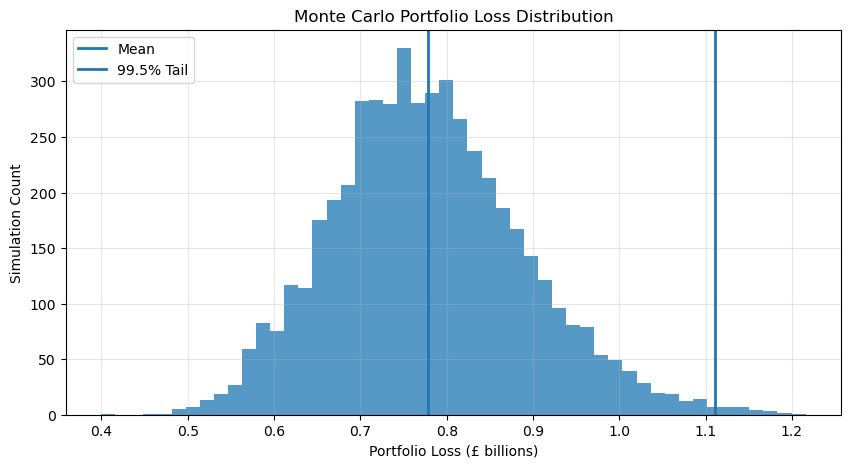

In [15]:
losses_cat_b = np.array(losses_cat) / 1e9

mean_loss = losses_cat_b.mean()
tail_loss = np.percentile(losses_cat_b, 99.5)

plt.figure(figsize=(10,5))

plt.hist(losses_cat_b, bins=50, alpha=0.75)

plt.axvline(mean_loss, linewidth=2, label="Mean")
plt.axvline(tail_loss, linewidth=2, label="99.5% Tail")

plt.title("Monte Carlo Portfolio Loss Distribution")
plt.xlabel("Portfolio Loss (£ billions)")
plt.ylabel("Simulation Count")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## Catastrophe-Style Exceedance Probability Curve

The exceedance probability curve is commonly used in catastrophe and
reinsurance modelling to describe the probability of portfolio losses
exceeding a given threshold.

Instead of presenting only a single percentile (e.g. the 99.5% capital
requirement), the EP curve shows the full tail behaviour of the loss
distribution.

The curve can also be expressed in terms of **return periods**, where:

Return period = 1 / exceedance probability

Examples:
- 1-in-10 year event → 10% exceedance probability
- 1-in-100 year event → 1% exceedance probability
- 1-in-200 year event → 0.5% exceedance probability

This representation is widely used in Lloyd’s catastrophe modelling
and Solvency II capital discussions.

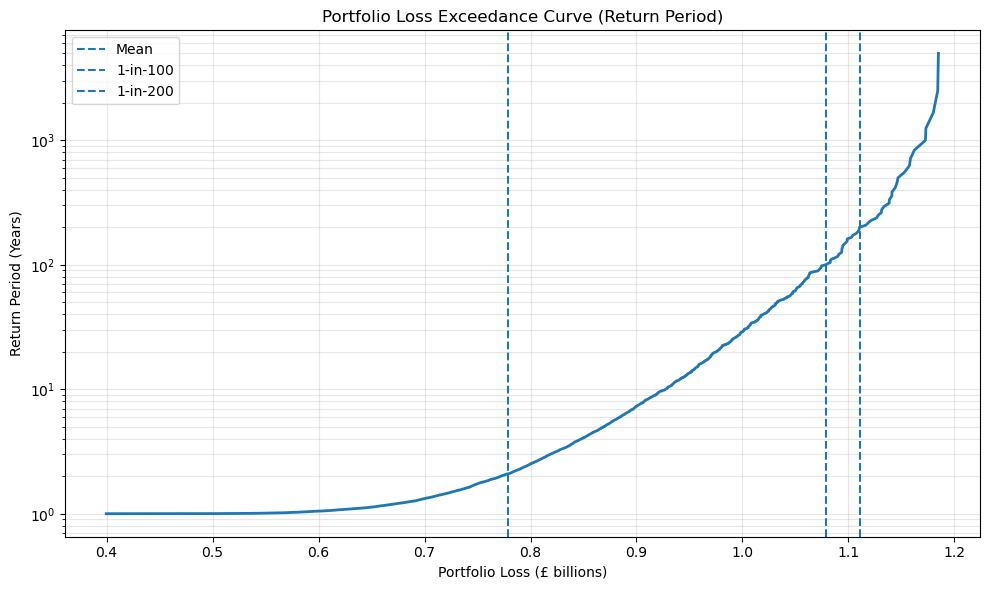

In [16]:
# Exceedance Probability (EP) Curve

losses_array = np.array(losses_cat if "losses_cat" in globals() else losses)

# Sort losses
loss_sorted = np.sort(losses_array)

n = len(loss_sorted)

# Exceedance probability
exceed_prob = 1 - (np.arange(1, n+1) / n)

# Convert to billions
loss_b = loss_sorted / 1e9

# Return period (years)
return_period = 1 / exceed_prob

# Key points
mean_loss = losses_array.mean()/1e9
p99 = np.percentile(losses_array,99)/1e9
p995 = np.percentile(losses_array,99.5)/1e9

plt.figure(figsize=(10,6))

plt.plot(loss_b, return_period, linewidth=2)

plt.axvline(mean_loss, linestyle="--", label="Mean")
plt.axvline(p99, linestyle="--", label="1-in-100")
plt.axvline(p995, linestyle="--", label="1-in-200")

plt.yscale("log")

plt.title("Portfolio Loss Exceedance Curve (Return Period)")
plt.xlabel("Portfolio Loss (£ billions)")
plt.ylabel("Return Period (Years)")

plt.grid(True, which="both", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
# Capital Stress (proxy)

SCR_MULTIPLIER = 1.35   # proxy scaling
RISK_MARGIN    = 0.05   # proxy margin

scr = SCR_MULTIPLIER * loss_p995
risk_margin = RISK_MARGIN * loss_p995

capital_required = float(scr + risk_margin)

capital_available = 50_000_000.0  # replace with scenario input later

solvency_ratio = capital_available / max(capital_required, 1e-9)

print(f"Capital required (proxy): {capital_required:,.0f}")
print(f"Capital available:        {capital_available:,.0f}")
print(f"Solvency ratio:           {solvency_ratio:.2f}")

Capital required (proxy): 1,554,604,724
Capital available:        50,000,000
Solvency ratio:           0.03


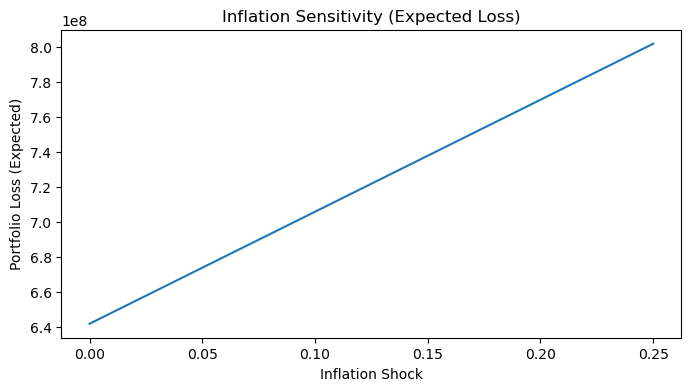

In [18]:
# Sensitivity Analysis

inflation_range = np.linspace(0, 0.25, 10)
sens = []

for infl in inflation_range:
    sev = mean_severity * (1 + infl)
    loss = (df["expected_frequency"] * sev).sum()
    sens.append(loss)

plt.figure(figsize=(8,4))
plt.plot(inflation_range, sens)
plt.xlabel("Inflation Shock")
plt.ylabel("Portfolio Loss (Expected)")
plt.title("Inflation Sensitivity (Expected Loss)")
plt.show()

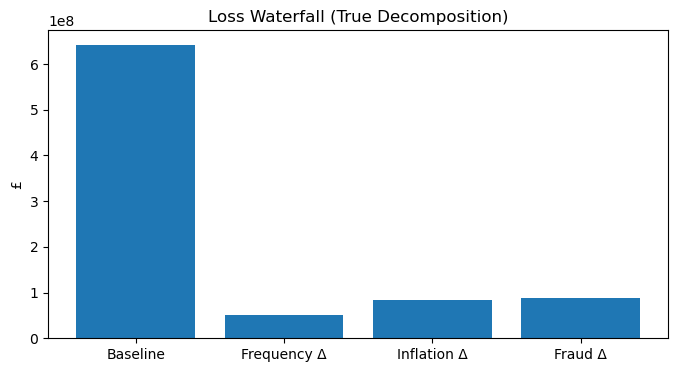

Baseline:     641,657,382
+ Frequency:  692,989,972
+ Inflation:  776,148,769
+ Fraud:      863,742,148


In [19]:
# Waterfall decomposition using true deltas

# Baseline (no shocks, no fraud overlay)
baseline_freq = df["expected_frequency"]
baseline_sev  = mean_severity
baseline_loss = float((baseline_freq * baseline_sev).sum())

# Frequency shock only
freq_only_loss = float((df["freq_stressed"] * baseline_sev).sum())

# Frequency + inflation
freq_infl_loss = float((df["freq_stressed"] * mean_severity_stressed).sum())

# Frequency + inflation + fraud overlay (final)
final_loss = float(portfolio_loss)

infl_delta  = freq_infl_loss - freq_only_loss
freq_delta  = freq_only_loss - baseline_loss
fraud_delta = final_loss - freq_infl_loss

labels = ["Baseline", "Frequency Δ", "Inflation Δ", "Fraud Δ"]
values = [baseline_loss, freq_delta, infl_delta, fraud_delta]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.title("Loss Waterfall (True Decomposition)")
plt.ylabel("£")
plt.show()

print(f"Baseline:     {baseline_loss:,.0f}")
print(f"+ Frequency:  {freq_only_loss:,.0f}")
print(f"+ Inflation:  {freq_infl_loss:,.0f}")
print(f"+ Fraud:      {final_loss:,.0f}")

In [20]:
# Governance Validation

checks = {
    "exposure_valid": bool((df["exposure"] >= 0).all()),
    "frequency_valid": bool((df["expected_frequency"] >= 0).all()),
    "fraud_layer_present": bool("fraud_adjusted_loss" in df.columns),
    "scenario_defined": bool(len(scenario) > 0),
    "relativity_prod_missing": int(df["relativity_prod"].isna().sum()),
    "relativity_channel_missing": int(df["relativity_channel"].isna().sum()),
}

for k, v in checks.items():
    print(k, v)

exposure_valid True
frequency_valid True
fraud_layer_present True
scenario_defined True
relativity_prod_missing 0
relativity_channel_missing 0


In [21]:
# Earned Premium Proxy

# Annual premium * exposure approximates earned premium
df["earned_premium_proxy"] = (
    df["base_annual_premium"] * df["exposure"]
)

print("Total earned premium:", df["earned_premium_proxy"].sum())

Total earned premium: 914909697.1736004


In [22]:
# Pricing optimizer base table (segment loss ratio)

seg = (
    df.groupby(["product_type", "channel"])
      .agg(
          loss=("fraud_adjusted_loss", "sum"),
          premium=("earned_premium_proxy", "sum"),
          exposure=("exposure", "sum")
      )
      .reset_index()
)

seg["loss_ratio"] = seg["loss"] / seg["premium"].clip(lower=1e-9)
seg.sort_values("loss_ratio", ascending=False).head(10)

,product_type,channel,loss,premium,exposure,loss_ratio
12,warranty,aggregator,2.094292e+07,7.757046e+06,2662.176591,2.699857
13,warranty,broker,7.178420e+07,2.880757e+07,9885.229295,2.491852
14,warranty,direct,3.681977e+07,1.569220e+07,5387.310062,2.346374
9,motor,aggregator,7.156545e+07,4.373002e+07,8111.444216,1.636529
10,motor,broker,2.411793e+08,1.599395e+08,29613.716632,1.507941
11,motor,direct,1.252222e+08,8.827533e+07,16336.810404,1.418541
3,health,aggregator,3.153922e+07,3.257676e+07,2242.464066,0.968151
4,health,broker,1.000027e+08,1.120514e+08,7702.724162,0.892471
5,health,direct,5.325040e+07,6.376373e+07,4358.015058,0.835121
0,gap,aggregator,3.437989e+06,5.271508e+06,1427.022587,0.652183


In [23]:
# Strategy Optimization

strategies = []

base_premium = float(df["earned_premium_proxy"].sum())
base_loss = float(df["fraud_adjusted_loss"].sum())

for rate in [0.05, 0.10, 0.15]:
    premium_new = base_premium * (1 + rate)
    profit = premium_new - base_loss
    strategies.append((rate, premium_new, base_loss, profit))

pd.DataFrame(strategies, columns=["rate_change","premium_new","loss","profit"])

,rate_change,premium_new,loss,profit
0,0.05,9.606552e+08,8.637421e+08,9.691303e+07
1,0.10,1.006401e+09,8.637421e+08,1.426585e+08
2,0.15,1.052146e+09,8.637421e+08,1.884040e+08


In [24]:
# Executive Summary Generator

exec_report = f"""
PHASE 8 — PORTFOLIO SCENARIO SUMMARY

Scenario:
- inflation_shock: {scenario["inflation_shock"]:.2%}
- frequency_shock: {scenario["frequency_shock"]:.2%}
- fraud_multiplier: {scenario["fraud_multiplier"]:.2f}

Expected loss (deterministic): {portfolio_loss:,.0f}

Monte Carlo:
- mean:  {loss_mean:,.0f}
- p95:   {loss_p95:,.0f}
- p99.5: {loss_p995:,.0f}

Capital proxy:
- required: {capital_required:,.0f}
- available: {capital_available:,.0f}
- solvency ratio: {solvency_ratio:.2f}
"""
print(exec_report)


PHASE 8 — PORTFOLIO SCENARIO SUMMARY

Scenario:
- inflation_shock: 12.00%
- frequency_shock: 8.00%
- fraud_multiplier: 1.25

Expected loss (deterministic): 863,742,148

Monte Carlo:
- mean:  778,896,816
- p95:   975,096,839
- p99.5: 1,110,431,946

Capital proxy:
- required: 1,554,604,724
- available: 50,000,000
- solvency ratio: 0.03



# A — Pricing Impact Layer

Scenario modelling quantifies portfolio risk.

However insurers respond to risk through **pricing decisions**.

This module converts stressed losses into pricing metrics:

• technical loss  
• earned premium proxy  
• loss ratio under stress  

This forms the base for rate optimisation.

In [25]:
df["base_annual_premium"]=pd.to_numeric(
    df["base_annual_premium"],
    errors="coerce"
).fillna(0)

df["earned_premium_proxy"]=df["base_annual_premium"]*df["exposure"]

portfolio_metrics={}

portfolio_metrics["earned_premium"]=df["earned_premium_proxy"].sum()
portfolio_metrics["stressed_loss"]=df["fraud_adjusted_loss"].sum()

portfolio_metrics["loss_ratio"]=(
    portfolio_metrics["stressed_loss"]/
    portfolio_metrics["earned_premium"]
)

portfolio_metrics

{'earned_premium': np.float64(914909697.1736004),
 'stressed_loss': np.float64(863742147.9688749),
 'loss_ratio': np.float64(0.944073661736458)}

# B — Dynamic Pricing Optimizer

Pricing teams adjust rates by segment rather than uniformly.

Segments used here:

• product_type
• channel

We simulate rate changes and measure:

• premium uplift
• loss ratio improvement

In [26]:
segments=(
    df.groupby(["product_type","channel"])
      .agg(
        premium=("earned_premium_proxy","sum"),
        loss=("fraud_adjusted_loss","sum")
      )
      .reset_index()
)

segments["loss_ratio"]=segments["loss"]/segments["premium"]

segments

,product_type,channel,premium,loss,loss_ratio
0,gap,aggregator,5.271508e+06,3.437989e+06,0.652183
1,gap,broker,1.948839e+07,1.168971e+07,0.599830
2,gap,direct,1.075438e+07,6.009256e+06,0.558773
3,health,aggregator,3.257676e+07,3.153922e+07,0.968151
4,health,broker,1.120514e+08,1.000027e+08,0.892471
5,health,direct,6.376373e+07,5.325040e+07,0.835121
6,home,aggregator,4.917877e+07,1.485691e+07,0.302100
7,home,broker,1.802012e+08,5.000891e+07,0.277517
8,home,direct,9.742193e+07,2.543331e+07,0.261063
9,motor,aggregator,4.373002e+07,7.156545e+07,1.636529


## Pricing Elasticity Layer

Rate changes do not affect premium volume mechanically.

Customer retention and new business volume typically respond to rate changes.

This module adds a simple elasticity framework so that pricing recommendations
reflect both:

- margin improvement
- retention / demand impact

In [27]:
# Pricing Elasticity Model

# Assumed elasticity by product type
# Negative means higher price -> lower retained premium volume
elasticity_map = {
    "motor": -1.2,
    "home": -0.8,
    "health": -0.6,
    "warranty": -0.9
}

segments["elasticity"] = segments["product_type"].map(elasticity_map).fillna(-1.0)

In [28]:
# Dynamic Pricing Optimizer with Elasticity

max_change = 0.15
target_lr = 0.70

segments["excess_lr"] = (segments["loss_ratio"] - target_lr).clip(lower=0)

if segments["excess_lr"].max() > 0:
    segments["score"] = segments["excess_lr"] / segments["excess_lr"].max()
else:
    segments["score"] = 0

segments["rate_change"] = max_change * segments["score"]
segments["rate_mult"] = 1 + segments["rate_change"]

# Retention adjustment using elasticity
# retained_premium = premium * (1 + rate_change) * (1 + elasticity * rate_change)
segments["retention_factor"] = (
    1 + segments["elasticity"] * segments["rate_change"]
).clip(lower=0.5, upper=1.05)

segments["premium_new"] = (
    segments["premium"] *
    segments["rate_mult"] *
    segments["retention_factor"]
)

segments["lr_new"] = segments["loss"] / segments["premium_new"].clip(lower=1e-9)

display(
    segments[[
        "product_type","channel","premium","loss","loss_ratio",
        "rate_change","elasticity","retention_factor","premium_new","lr_new"
    ]].sort_values("loss_ratio", ascending=False).head(12)
)

,product_type,channel,premium,loss,loss_ratio,rate_change,elasticity,retention_factor,premium_new,lr_new
12,warranty,aggregator,7.757046e+06,2.094292e+07,2.699857,0.150000,-0.9,0.865000,7.716321e+06,2.714106
13,warranty,broker,2.880757e+07,7.178420e+07,2.491852,0.134398,-0.9,0.879041,2.872643e+07,2.498891
14,warranty,direct,1.569220e+07,3.681977e+07,2.346374,0.123487,-0.9,0.888862,1.567061e+07,2.349606
9,motor,aggregator,4.373002e+07,7.156545e+07,1.636529,0.070245,-1.2,0.915706,4.285673e+07,1.669877
10,motor,broker,1.599395e+08,2.411793e+08,1.507941,0.060600,-1.2,0.927280,1.572962e+08,1.533281
11,motor,direct,8.827533e+07,1.252222e+08,1.418541,0.053894,-1.2,0.935327,8.701614e+07,1.439069
3,health,aggregator,3.257676e+07,3.153922e+07,0.968151,0.020113,-0.6,0.987932,3.283093e+07,0.960656
4,health,broker,1.120514e+08,1.000027e+08,0.892471,0.014436,-0.6,0.991338,1.126844e+08,0.887458
5,health,direct,6.376373e+07,5.325040e+07,0.835121,0.010135,-0.6,0.993919,6.401830e+07,0.831800
0,gap,aggregator,5.271508e+06,3.437989e+06,0.652183,0.000000,-1.0,1.000000,5.271508e+06,0.652183


# C — Executive Decision Summary

Senior leadership requires a concise interpretation of analytical results.

This module generates a structured executive summary.

In [29]:
report=f"""

PORTFOLIO SCENARIO SUMMARY

Expected Loss:
{loss_mean:,.0f}

99.5% Tail Risk:
{loss_p995:,.0f}

Capital Required:
{capital_required:,.0f}

Solvency Ratio:
{solvency_ratio:.2f}

Pricing Impact

Current Loss Ratio:
{portfolio_metrics["loss_ratio"]:.2f}

Recommendation

Targeted rate increases in high loss-ratio segments.

"""

print(report)



PORTFOLIO SCENARIO SUMMARY

Expected Loss:
778,896,816

99.5% Tail Risk:
1,110,431,946

Capital Required:
1,554,604,724

Solvency Ratio:
0.03

Pricing Impact

Current Loss Ratio:
0.94

Recommendation

Targeted rate increases in high loss-ratio segments.




# D — Portfolio Strategy Optimizer

Portfolio decisions involve multiple levers:

• pricing changes
• fraud investigation capacity
• reinsurance

This module evaluates combinations of these levers
and identifies the strategy that maximises profitability
while maintaining solvency.

In [30]:
# Portfolio Strategy Optimizer (Elasticity-aware)

strategies = []

base_loss = df["fraud_adjusted_loss"].sum()

for rate in [0.05, 0.10, 0.15]:
    
    temp = segments.copy()
    temp["rate_change"] = rate
    temp["rate_mult"] = 1 + temp["rate_change"]
    
    temp["retention_factor"] = (
        1 + temp["elasticity"] * temp["rate_change"]
    ).clip(lower=0.5, upper=1.05)
    
    temp["premium_new"] = (
        temp["premium"] *
        temp["rate_mult"] *
        temp["retention_factor"]
    )
    
    total_premium = temp["premium_new"].sum()
    profit = total_premium - base_loss
    
    strategies.append((rate, total_premium, base_loss, profit))

strategy_table = pd.DataFrame(
    strategies,
    columns=["rate_change","premium_new","loss","profit"]
)

display(strategy_table)

,rate_change,premium_new,loss,profit
0,0.05,9.176390e+08,8.637421e+08,5.389685e+07
1,0.10,9.162715e+08,8.637421e+08,5.252938e+07
2,0.15,9.108073e+08,8.637421e+08,4.706512e+07


# Portfolio Risk Dashboard

This dashboard summarises the key outputs of the Digital Twin:

• loss distribution  
• scenario sensitivity  
• capital position  
• portfolio risk metrics

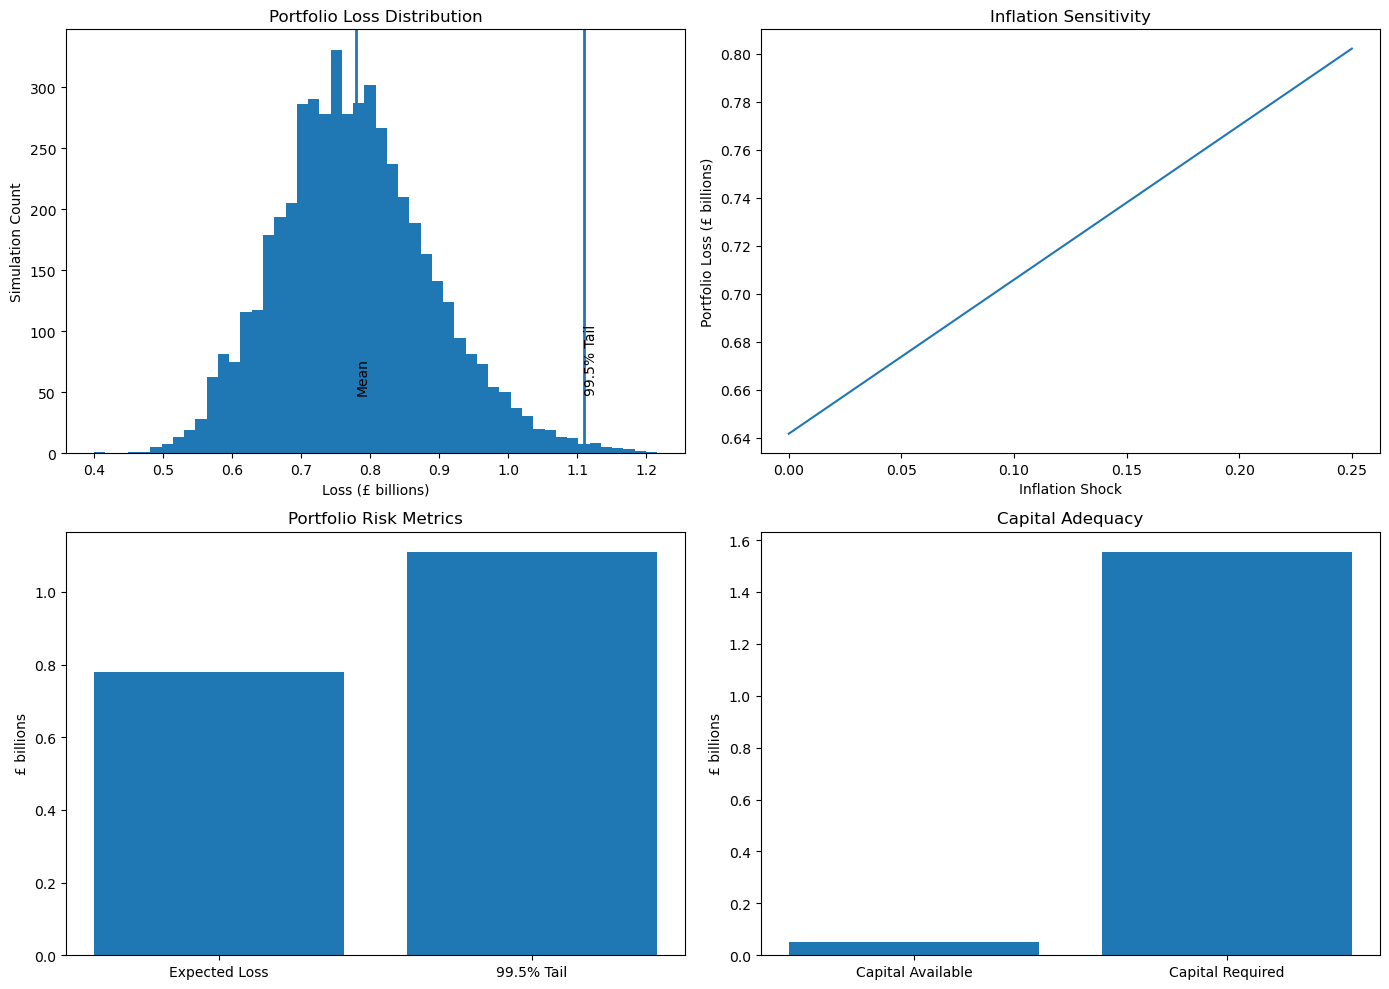

Saved dashboard: outputs\phase8\phase8_portfolio_risk_dashboard.png


In [31]:
OUT = Path("outputs/phase8")
OUT.mkdir(exist_ok=True)

# Convert to billions for readability
losses_b = losses / 1e9
loss_mean_b = loss_mean / 1e9
loss_p995_b = loss_p995 / 1e9
capital_available_b = capital_available / 1e9
capital_required_b = capital_required / 1e9

fig, axs = plt.subplots(2, 2, figsize=(14,10))

# Loss Distribution

axs[0,0].hist(losses_b, bins=50)
axs[0,0].axvline(loss_mean_b, linewidth=2)
axs[0,0].axvline(loss_p995_b, linewidth=2)

axs[0,0].set_title("Portfolio Loss Distribution")
axs[0,0].set_xlabel("Loss (£ billions)")
axs[0,0].set_ylabel("Simulation Count")

axs[0,0].text(loss_mean_b, 50, "Mean", rotation=90)
axs[0,0].text(loss_p995_b, 50, "99.5% Tail", rotation=90)

# Inflation Sensitivity

sens_b = np.array(sens) / 1e9

axs[0,1].plot(inflation_range, sens_b)

axs[0,1].set_title("Inflation Sensitivity")
axs[0,1].set_xlabel("Inflation Shock")
axs[0,1].set_ylabel("Portfolio Loss (£ billions)")


# Risk Metrics

axs[1,0].bar(["Expected Loss","99.5% Tail"], [loss_mean_b, loss_p995_b])
axs[1,0].set_title("Portfolio Risk Metrics")
axs[1,0].set_ylabel("£ billions")

# Capital Position

axs[1,1].bar(
    ["Capital Available","Capital Required"],
    [capital_available_b, capital_required_b]
)

axs[1,1].set_title("Capital Adequacy")
axs[1,1].set_ylabel("£ billions")

plt.tight_layout()

fig_path = OUT / "phase8_portfolio_risk_dashboard.png"

plt.savefig(fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved dashboard:", fig_path)

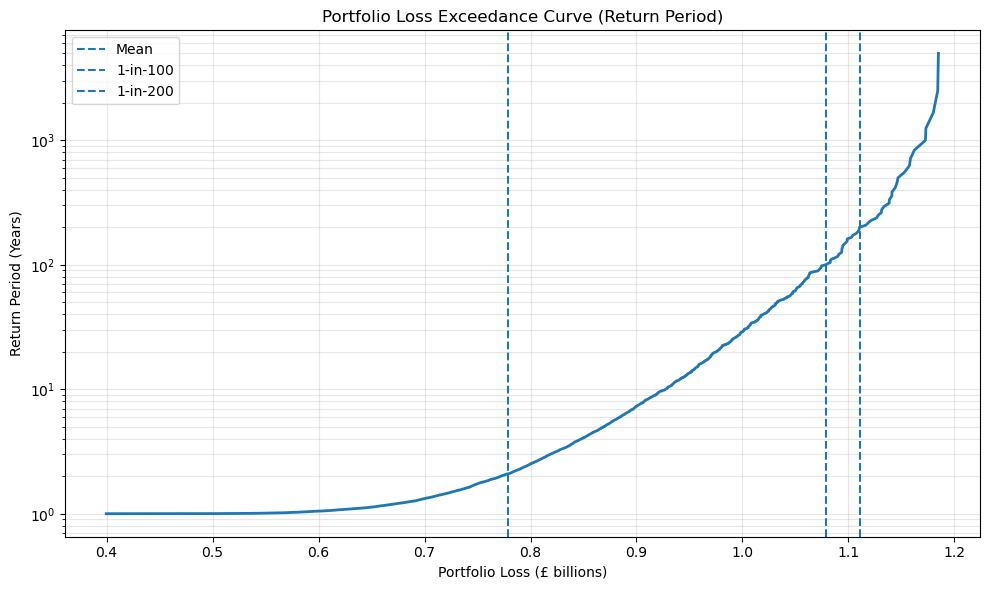

Saved: outputs\phase8\phase8_ep_curve_lloyds_style.png


In [32]:
# Lloyd's Style EP Curve (Return Period View)

OUT = Path("outputs/phase8")
OUT.mkdir(exist_ok=True)

losses_array = np.array(losses_cat if "losses_cat" in globals() else losses)

# Sort losses
loss_sorted = np.sort(losses_array)

n = len(loss_sorted)

# Exceedance probability
exceed_prob = 1 - (np.arange(1, n+1) / n)

# Convert to billions
loss_b = loss_sorted / 1e9

# Return period (years)
return_period = 1 / exceed_prob

# Key points
mean_loss = losses_array.mean()/1e9
p99 = np.percentile(losses_array,99)/1e9
p995 = np.percentile(losses_array,99.5)/1e9

plt.figure(figsize=(10,6))

plt.plot(loss_b, return_period, linewidth=2)

plt.axvline(mean_loss, linestyle="--", label="Mean")
plt.axvline(p99, linestyle="--", label="1-in-100")
plt.axvline(p995, linestyle="--", label="1-in-200")

plt.yscale("log")

plt.title("Portfolio Loss Exceedance Curve (Return Period)")
plt.xlabel("Portfolio Loss (£ billions)")
plt.ylabel("Return Period (Years)")

plt.grid(True, which="both", alpha=0.3)

plt.legend()

plt.tight_layout()

ep_path = OUT / "phase8_ep_curve_lloyds_style.png"
plt.savefig(ep_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved:", ep_path)

In [34]:
OUT = Path("outputs/phase8")
OUT.mkdir(exist_ok=True)

# 1) loss distribution
pd.DataFrame({"loss_distribution": losses_cat}).to_csv(OUT/"loss_distribution_mc.csv", index=False)

# 2) scenario summary table
scenario_summary = pd.DataFrame([{
    "inflation_shock": scenario["inflation_shock"],
    "frequency_shock": scenario["frequency_shock"],
    "fraud_multiplier": scenario["fraud_multiplier"],
    "expected_loss_deterministic": float(portfolio_loss),
    "mc_mean": loss_mean,
    "mc_p95": loss_p95,
    "mc_p995": loss_p995,
    "portfolio_lambda": float(portfolio_lambda),
    "capital_required_proxy": float(capital_required),
    "capital_available": float(capital_available),
    "solvency_ratio": float(solvency_ratio),
}])
scenario_summary.to_csv(OUT/"scenario_summary.csv", index=False)

# 3) capital metrics json
capital_metrics = {
    "loss_mean": loss_mean,
    "loss_p05": loss_p05,
    "loss_p95": loss_p95,
    "loss_p995": loss_p995,
    "capital_required": float(capital_required),
    "capital_available": float(capital_available),
    "solvency_ratio": float(solvency_ratio),
    "scr_multiplier": SCR_MULTIPLIER,
    "risk_margin": RISK_MARGIN,
}
with open(OUT/"phase8_capital_metrics.json","w") as f:
    json.dump(capital_metrics, f, indent=2)

# 4) EP metrics json
ep_losses = np.array(losses_array)

# Key EP metrics
mean_loss = ep_losses.mean()
p99 = np.percentile(ep_losses, 99)
p995 = np.percentile(ep_losses, 99.5)
max_loss = ep_losses.max()

# Tail Value at Risk (TVaR) for 99%
tvar_99 = ep_losses[ep_losses >= p99].mean()

ep_metrics = {
    "mean_loss_bn": float(mean_loss / 1e9),
    "loss_1_in_100_bn": float(p99 / 1e9),
    "loss_1_in_200_bn": float(p995 / 1e9),
    "tvar_99_bn": float(tvar_99 / 1e9),
    "max_loss_bn": float(max_loss / 1e9),
    "simulation_count": int(len(ep_losses))
}

with open(OUT / "phase8_ep_metrics.json", "w") as f:
    json.dump(ep_metrics, f, indent=2)

print("Saved:", OUT / "phase8_ep_metrics.json")

# 5) governance checks json
with open(OUT/"phase8_governance_checks.json","w") as f:
    json.dump(checks, f, indent=2)

# 6) executive report txt
with open(OUT/"phase8_exec_report.txt","w") as f:
    f.write(exec_report)

print("Phase 8 export pack written to:", OUT)

Saved: outputs\phase8\phase8_ep_metrics.json
Phase 8 export pack written to: outputs\phase8
